Libraries loaded!
XGBoost version: 3.0.2

  PART A: CAFETERIA XGBoost
Daily rows: 700
After lag drop: 679 rows remain
Train: 543 | Test: 136

Training XGBoost on Cafeteria data...
[0]	validation_0-mae:9283436.17647
[50]	validation_0-mae:2428004.33088
[100]	validation_0-mae:754461.19853
[150]	validation_0-mae:212149.78676
[200]	validation_0-mae:135401.54412
[250]	validation_0-mae:121654.11029
[300]	validation_0-mae:119937.57721
[350]	validation_0-mae:118720.91912
[400]	validation_0-mae:117665.38603
[450]	validation_0-mae:117145.57721
[500]	validation_0-mae:116593.17647
[550]	validation_0-mae:116299.67279
[600]	validation_0-mae:116262.02941
Cafeteria XGBoost training complete!
Best iteration: 570

  XGBoost — Cafeteria
  MAE  :         116,203 UGX
  RMSE :         192,721 UGX
  MAPE :           0.64 %

Top 10 features (Cafeteria):
            feature  importance
Academic_Period_num    0.308686
Ingredient_Cost_UGX    0.093618
         Is_Weekend    0.092882
  Portions_Prepared    0.060883

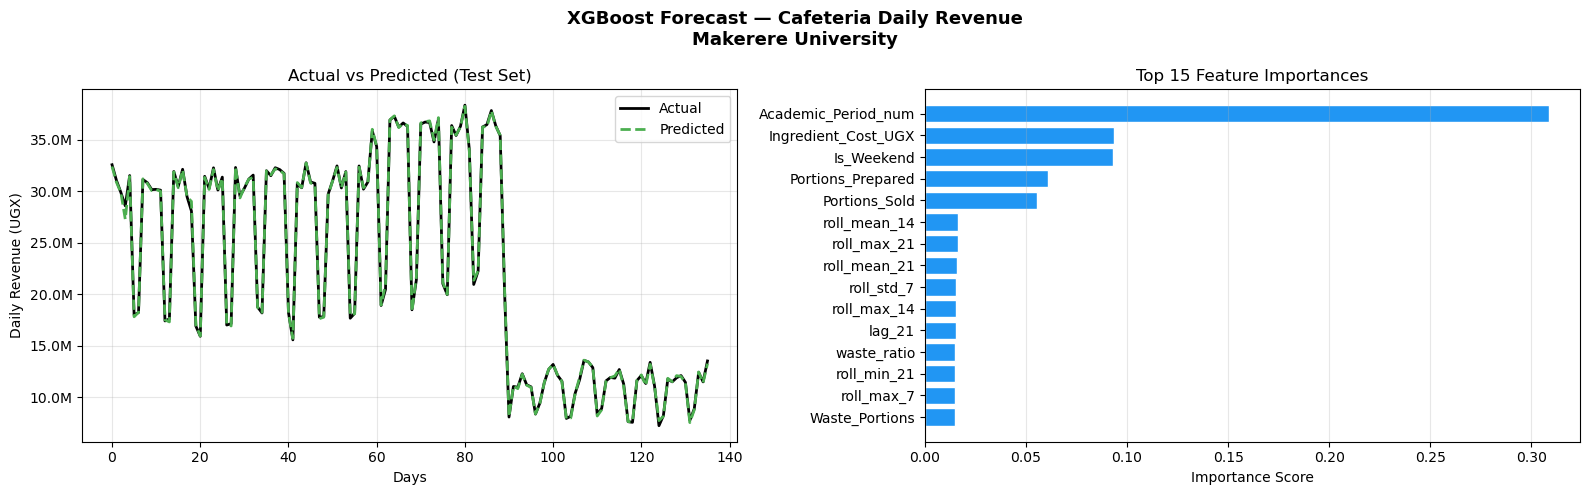

Plot saved: xgb_cafeteria_results.png

  PART B: KIOSK XGBoost
Daily kiosk rows: 700
After lag drop: 679 rows remain

Training XGBoost on Kiosk data...
[0]	validation_0-mae:141360.51103
[50]	validation_0-mae:33209.56388
[100]	validation_0-mae:9208.31756
[150]	validation_0-mae:5222.55687
[200]	validation_0-mae:3855.32247
[250]	validation_0-mae:3456.46826
[300]	validation_0-mae:3300.33611
[350]	validation_0-mae:3260.57633
[400]	validation_0-mae:3205.65984
[450]	validation_0-mae:3150.24358
[500]	validation_0-mae:3129.40470
[550]	validation_0-mae:3117.52134
[600]	validation_0-mae:3104.14400
[650]	validation_0-mae:3072.40273
[686]	validation_0-mae:3069.92696
Kiosk XGBoost training complete!

  XGBoost — Kiosk
  MAE  :           3,068 UGX
  RMSE :           4,391 UGX
  MAPE :           1.66 %

Top 10 features (Kiosk):
              feature  importance
     Num_Transactions    0.111145
       Total_Quantity    0.103403
  Academic_Period_num    0.099671
avg_transaction_value    0.040998
      

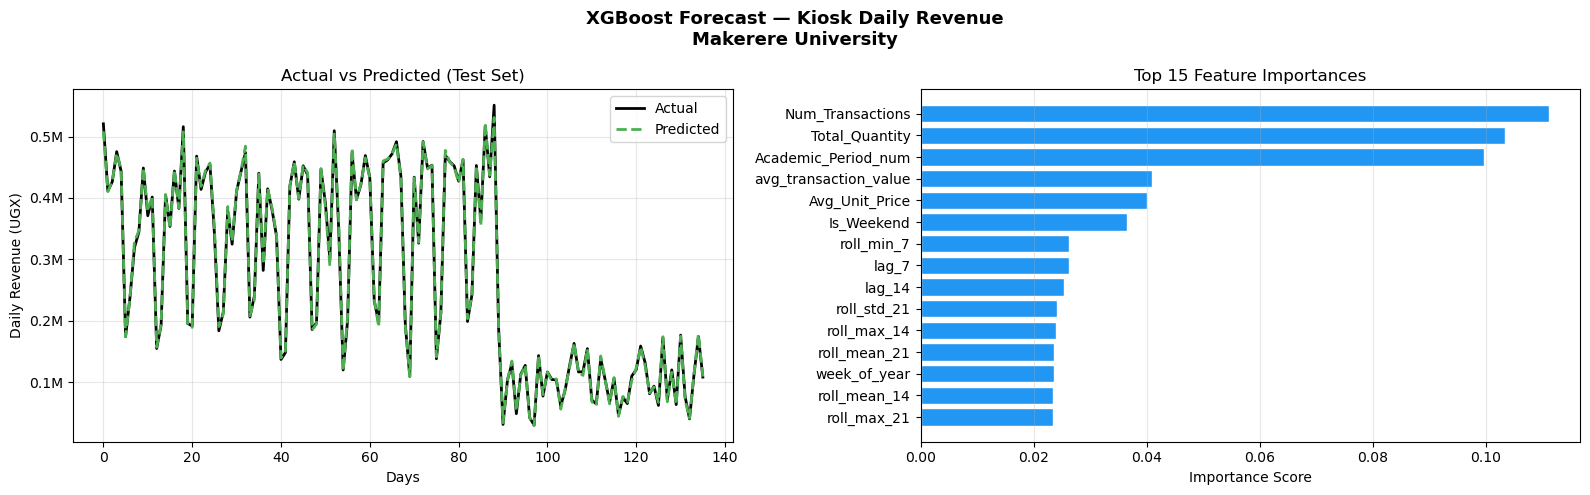

Plot saved: xgb_kiosk_results.png

Models saved to ./models/

╔══════════════════════════════════════════════════════╗
║           XGBoost RESULTS SUMMARY                   ║
╠══════════════════════════════════════════════════════╣
║  CAFETERIA (Target: Daily Revenue_UGX)              ║
║    MAE  :         116,203 UGX               ║
║    RMSE :         192,721 UGX               ║
║    MAPE :           0.64 %                  ║
╠══════════════════════════════════════════════════════╣
║  KIOSK (Target: Daily Total_Amount_UGX)             ║
║    MAE  :           3,068 UGX               ║
║    RMSE :           4,391 UGX               ║
║    MAPE :           1.66 %                  ║
╚══════════════════════════════════════════════════════╝

OUTPUT FILES:
  xgb_cafeteria_results.png  — Forecast + feature importance
  xgb_kiosk_results.png      — Forecast + feature importance
  models/xgb_cafeteria.json  — Saved cafeteria model
  models/xgb_kiosk.json      — Saved kiosk model



In [1]:
# ============================================================
#  XGBoost Demand Forecasting — Makerere Food Supply Chain
#  Datasets: Cafeteria + Kiosk → Predict Daily Total Revenue
#
#  WHY XGBoost OVER LSTM HERE?
#  - XGBoost excels at tabular data with hand-crafted lag features
#  - Faster to train, easier to tune, and often more accurate
#  - We manually give it the "memory" LSTM learns automatically
#    by engineering lag features (yesterday, 7 days ago, etc.)
#  - LSTM vs XGBoost results are compared at the end
#
#  INSTALL (once):
#  pip install xgboost pandas numpy matplotlib scikit-learn shap
# ============================================================


# ============================================================
# STEP 1 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, pickle, os
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb

np.random.seed(42)

print("Libraries loaded!")
print(f"XGBoost version: {xgb.__version__}")


# ============================================================
# STEP 2 — SHARED HELPER FUNCTIONS
# ============================================================

def clean_currency(series):
    """Remove commas and convert to float."""
    return series.astype(str).str.replace(",", "", regex=False).astype(float)


def evaluate_model(actual, predicted, model_name):
    """Print MAE, RMSE, MAPE."""
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  MAE  : {mae:>15,.0f} UGX")
    print(f"  RMSE : {rmse:>15,.0f} UGX")
    print(f"  MAPE : {mape:>14.2f} %")
    return mae, rmse, mape


def make_lag_features(df, target_col, lags, windows):
    """
    Engineer lag + rolling features — this gives XGBoost its 'memory'.

    WHAT THIS DOES:
    XGBoost sees each row independently (no sequence memory like LSTM).
    So we manually add columns:
      - lag_1  = yesterday's revenue  (most predictive single feature)
      - lag_7  = same day last week   (captures weekly seasonality)
      - lag_14 = two weeks ago        (captures bi-weekly patterns)
      - rolling_mean_7  = avg of past 7 days  (smoothed trend)
      - rolling_std_7   = volatility of past 7 days

    These transform a static table into a time-aware feature set.
    """
    df = df.copy()
    for lag in lags:
        df[f"lag_{lag}"] = df[target_col].shift(lag)
    for w in windows:
        df[f"roll_mean_{w}"] = df[target_col].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df[target_col].shift(1).rolling(w).std()
        df[f"roll_max_{w}"]  = df[target_col].shift(1).rolling(w).max()
        df[f"roll_min_{w}"]  = df[target_col].shift(1).rolling(w).min()
    return df


def add_calendar_features(df, date_col="Date"):
    """Add day-of-week, month, week-of-year, quarter features."""
    df = df.copy()
    df["day_of_week"]  = df[date_col].dt.dayofweek      # 0=Mon … 6=Sun
    df["month"]        = df[date_col].dt.month
    df["week_of_year"] = df[date_col].dt.isocalendar().week.astype(int)
    df["quarter"]      = df[date_col].dt.quarter
    df["day_of_month"] = df[date_col].dt.day
    df["is_month_end"] = df[date_col].dt.is_month_end.astype(int)
    return df


def plot_xgb_results(actual, predicted, feature_importance, title, filename):
    """Plot actual vs predicted + top feature importances."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # Left: Actual vs Predicted
    axes[0].plot(actual,    label="Actual",    color="black",  linewidth=2)
    axes[0].plot(predicted, label="Predicted", color="#4CAF50",
                 linewidth=2, linestyle="--")
    axes[0].set_title("Actual vs Predicted (Test Set)")
    axes[0].set_xlabel("Days")
    axes[0].set_ylabel("Daily Revenue (UGX)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

    # Right: Feature Importance (top 15)
    top_feats = feature_importance.nlargest(15, "importance")
    axes[1].barh(top_feats["feature"], top_feats["importance"],
                 color="#2196F3", edgecolor="white")
    axes[1].set_title("Top 15 Feature Importances")
    axes[1].set_xlabel("Importance Score")
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved: {filename}")


# ============================================================
# STEP 3 — LOAD & AGGREGATE CAFETERIA
# ============================================================
print("\n" + "="*55)
print("  PART A: CAFETERIA XGBoost")
print("="*55)

period_map = {
    "Sem1_Teaching": 1, "Sem1_Exams": 2, "Sem1_Break": 3,
    "Sem2_Teaching": 4, "Sem2_Exams": 5, "Sem2_Break": 6
}

cafe_raw = pd.read_csv("makerere_Cafeteria_synthetic.csv")

for col in ["Revenue_UGX", "Ingredient_Cost_UGX",
            "Waste_Cost_UGX", "Gross_Profit_UGX"]:
    cafe_raw[col] = clean_currency(cafe_raw[col])

cafe_raw["Date"]       = pd.to_datetime(cafe_raw["Date"])
cafe_raw["Is_Weekend"] = cafe_raw["Is_Weekend"].astype(int)
cafe_raw["Academic_Period_num"] = cafe_raw["Academic_Period"].map(period_map).fillna(0)

cafe_daily = cafe_raw.groupby("Date").agg(
    Revenue_UGX         = ("Revenue_UGX",          "sum"),
    Portions_Sold       = ("Portions_Sold",         "sum"),
    Portions_Prepared   = ("Portions_Prepared",     "sum"),
    Waste_Portions      = ("Waste_Portions",        "sum"),
    Waste_Pct           = ("Waste_Pct",             "mean"),
    Gross_Profit_UGX    = ("Gross_Profit_UGX",      "sum"),
    Ingredient_Cost_UGX = ("Ingredient_Cost_UGX",   "sum"),
    Is_Weekend          = ("Is_Weekend",            "first"),
    Academic_Period_num = ("Academic_Period_num",   "first"),
).reset_index().sort_values("Date")

print(f"Daily rows: {len(cafe_daily)}")


# ============================================================
# STEP 4 — FEATURE ENGINEERING (CAFETERIA)
# ============================================================
# Add lag & rolling features
LAGS    = [1, 2, 3, 7, 14, 21]   # days to look back
WINDOWS = [7, 14, 21]            # rolling window sizes

cafe_feat = make_lag_features(cafe_daily, "Revenue_UGX", LAGS, WINDOWS)
cafe_feat = add_calendar_features(cafe_feat, "Date")

# Profit margin ratio (business signal)
cafe_feat["profit_margin"] = (
    cafe_feat["Gross_Profit_UGX"] / cafe_feat["Revenue_UGX"].replace(0, np.nan)
).fillna(0)

# Waste efficiency ratio
cafe_feat["waste_ratio"] = (
    cafe_feat["Waste_Portions"] / cafe_feat["Portions_Prepared"].replace(0, np.nan)
).fillna(0)

# Drop rows with NaN from lag creation (first 21 rows)
cafe_feat.dropna(inplace=True)
print(f"After lag drop: {len(cafe_feat)} rows remain")

TARGET_CAFE = "Revenue_UGX"
DROP_COLS   = ["Date", TARGET_CAFE, "Gross_Profit_UGX"]  # avoid leakage
FEATURE_COLS_CAFE = [c for c in cafe_feat.columns if c not in DROP_COLS]

X_cafe = cafe_feat[FEATURE_COLS_CAFE]
y_cafe = cafe_feat[TARGET_CAFE]


# ============================================================
# STEP 5 — TIME-SERIES TRAIN/TEST SPLIT (CAFETERIA)
# Walk-forward: first 80% train, last 20% test (no shuffle!)
# ============================================================
split_idx = int(len(X_cafe) * 0.8)
X_train_c, X_test_c = X_cafe.iloc[:split_idx], X_cafe.iloc[split_idx:]
y_train_c, y_test_c = y_cafe.iloc[:split_idx], y_cafe.iloc[split_idx:]

print(f"Train: {len(X_train_c)} | Test: {len(X_test_c)}")


# ============================================================
# STEP 6 — TRAIN XGBoost (CAFETERIA)
#
#  KEY HYPERPARAMETERS EXPLAINED:
#  n_estimators    : number of trees (more = more powerful, slower)
#  max_depth       : max depth per tree (3-6 avoids overfitting)
#  learning_rate   : step size shrinkage (smaller = more stable)
#  subsample       : fraction of rows per tree (reduces overfitting)
#  colsample_bytree: fraction of features per tree (prevents overfit)
#  min_child_weight: minimum observations in a leaf (prevents overfit)
#  early_stopping  : stop if val score doesn't improve for N rounds
# ============================================================
xgb_cafe = xgb.XGBRegressor(
    n_estimators      = 1000,
    max_depth         = 5,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,    # L1 regularisation
    reg_lambda        = 1.0,    # L2 regularisation
    objective         = "reg:absoluteerror",  # minimise MAE directly
    random_state      = 42,
    n_jobs            = -1,
    early_stopping_rounds = 30,
    eval_metric       = "mae",
)

print("\nTraining XGBoost on Cafeteria data...")
xgb_cafe.fit(
    X_train_c, y_train_c,
    eval_set    = [(X_test_c, y_test_c)],
    verbose     = 50,   # print every 50 rounds
)
print("Cafeteria XGBoost training complete!")
print(f"Best iteration: {xgb_cafe.best_iteration}")


# ============================================================
# STEP 7 — EVALUATE (CAFETERIA)
# ============================================================
y_pred_c = xgb_cafe.predict(X_test_c)

mae_c, rmse_c, mape_c = evaluate_model(
    y_test_c.values, y_pred_c, "XGBoost — Cafeteria"
)

# Feature importance DataFrame
fi_cafe = pd.DataFrame({
    "feature":    FEATURE_COLS_CAFE,
    "importance": xgb_cafe.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 features (Cafeteria):")
print(fi_cafe.head(10).to_string(index=False))

plot_xgb_results(
    y_test_c.values, y_pred_c, fi_cafe,
    "XGBoost Forecast — Cafeteria Daily Revenue\nMakerere University",
    "xgb_cafeteria_results.png"
)


# ============================================================
# STEP 8 — LOAD & AGGREGATE KIOSK
# ============================================================
print("\n" + "="*55)
print("  PART B: KIOSK XGBoost")
print("="*55)

kiosk_raw = pd.read_csv("makerere_kiosk_synthetic.csv")
kiosk_raw["Total_Amount_UGX"]  = clean_currency(kiosk_raw["Total_Amount_UGX"])
kiosk_raw["Unit_Price_UGX"]    = clean_currency(kiosk_raw["Unit_Price_UGX"])
kiosk_raw["Date"]              = pd.to_datetime(kiosk_raw["Date"])
kiosk_raw["Is_Weekend"]        = kiosk_raw["Is_Weekend"].astype(int)
kiosk_raw["Near_Lecture_Start"]= kiosk_raw["Near_Lecture_Start"].astype(int)
kiosk_raw["Academic_Period_num"]= kiosk_raw["Academic_Period"].map(period_map).fillna(0)

kiosk_daily = kiosk_raw.groupby("Date").agg(
    Total_Amount_UGX    = ("Total_Amount_UGX",   "sum"),
    Num_Transactions    = ("Transaction_ID",      "count"),
    Avg_Unit_Price      = ("Unit_Price_UGX",      "mean"),
    Total_Quantity      = ("Quantity",            "sum"),
    Is_Weekend          = ("Is_Weekend",          "first"),
    Near_Lecture_Start  = ("Near_Lecture_Start",  "mean"),
    Academic_Period_num = ("Academic_Period_num", "first"),
).reset_index().sort_values("Date")

print(f"Daily kiosk rows: {len(kiosk_daily)}")


# ============================================================
# STEP 9 — FEATURE ENGINEERING (KIOSK)
# ============================================================
kiosk_feat = make_lag_features(kiosk_daily, "Total_Amount_UGX", LAGS, WINDOWS)
kiosk_feat = add_calendar_features(kiosk_feat, "Date")

# Revenue per transaction (efficiency metric)
kiosk_feat["avg_transaction_value"] = (
    kiosk_feat["Total_Amount_UGX"] /
    kiosk_feat["Num_Transactions"].replace(0, np.nan)
).fillna(0)

kiosk_feat.dropna(inplace=True)
print(f"After lag drop: {len(kiosk_feat)} rows remain")

TARGET_KIOSK = "Total_Amount_UGX"
DROP_KIOSK   = ["Date", TARGET_KIOSK]
FEATURE_COLS_KIOSK = [c for c in kiosk_feat.columns if c not in DROP_KIOSK]

X_kiosk = kiosk_feat[FEATURE_COLS_KIOSK]
y_kiosk = kiosk_feat[TARGET_KIOSK]


# ============================================================
# STEP 10 — TRAIN/TEST SPLIT + TRAIN XGBoost (KIOSK)
# ============================================================
split_k = int(len(X_kiosk) * 0.8)
X_train_k, X_test_k = X_kiosk.iloc[:split_k], X_kiosk.iloc[split_k:]
y_train_k, y_test_k = y_kiosk.iloc[:split_k], y_kiosk.iloc[split_k:]

xgb_kiosk = xgb.XGBRegressor(
    n_estimators      = 1000,
    max_depth         = 4,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.05,
    reg_lambda        = 1.0,
    objective         = "reg:absoluteerror",
    random_state      = 42,
    n_jobs            = -1,
    early_stopping_rounds = 30,
    eval_metric       = "mae",
)

print("\nTraining XGBoost on Kiosk data...")
xgb_kiosk.fit(
    X_train_k, y_train_k,
    eval_set  = [(X_test_k, y_test_k)],
    verbose   = 50,
)
print("Kiosk XGBoost training complete!")


# ============================================================
# STEP 11 — EVALUATE (KIOSK)
# ============================================================
y_pred_k = xgb_kiosk.predict(X_test_k)

mae_k, rmse_k, mape_k = evaluate_model(
    y_test_k.values, y_pred_k, "XGBoost — Kiosk"
)

fi_kiosk = pd.DataFrame({
    "feature":    FEATURE_COLS_KIOSK,
    "importance": xgb_kiosk.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 features (Kiosk):")
print(fi_kiosk.head(10).to_string(index=False))

plot_xgb_results(
    y_test_k.values, y_pred_k, fi_kiosk,
    "XGBoost Forecast — Kiosk Daily Revenue\nMakerere University",
    "xgb_kiosk_results.png"
)


# ============================================================
# STEP 12 — SAVE MODELS + FEATURE LISTS FOR DEPLOYMENT
# ============================================================
os.makedirs("models", exist_ok=True)

xgb_cafe.save_model("models/xgb_cafeteria.json")
xgb_kiosk.save_model("models/xgb_kiosk.json")

# Save feature column names (must match at prediction time)
with open("models/cafe_features.pkl",  "wb") as f:
    pickle.dump(FEATURE_COLS_CAFE,  f)
with open("models/kiosk_features.pkl", "wb") as f:
    pickle.dump(FEATURE_COLS_KIOSK, f)

print("\nModels saved to ./models/")


# ============================================================
# STEP 13 — FINAL SUMMARY
# ============================================================
print(f"""
╔══════════════════════════════════════════════════════╗
║           XGBoost RESULTS SUMMARY                   ║
╠══════════════════════════════════════════════════════╣
║  CAFETERIA (Target: Daily Revenue_UGX)              ║
║    MAE  : {mae_c:>15,.0f} UGX               ║
║    RMSE : {rmse_c:>15,.0f} UGX               ║
║    MAPE : {mape_c:>14.2f} %                  ║
╠══════════════════════════════════════════════════════╣
║  KIOSK (Target: Daily Total_Amount_UGX)             ║
║    MAE  : {mae_k:>15,.0f} UGX               ║
║    RMSE : {rmse_k:>15,.0f} UGX               ║
║    MAPE : {mape_k:>14.2f} %                  ║
╚══════════════════════════════════════════════════════╝

OUTPUT FILES:
  xgb_cafeteria_results.png  — Forecast + feature importance
  xgb_kiosk_results.png      — Forecast + feature importance
  models/xgb_cafeteria.json  — Saved cafeteria model
  models/xgb_kiosk.json      — Saved kiosk model
""")